# Agumentated Data for the LFW

In [1]:
from google.colab import drive
drive.mount('/content/gdrive')

Mounted at /content/gdrive


In [2]:
!pip install opencv-python

In [3]:
import pandas as pd
import numpy as np
import cv2
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import f1_score
from tensorflow.keras.preprocessing.image import ImageDataGenerator, array_to_img, img_to_array, load_img


plt.style.use('ggplot')

%matplotlib inline

In [31]:
# set variables
main_folder = '/content/gdrive/My Drive/Masters'
images_folder = main_folder + '/lfw-deepfunneled/lfw-deepfunneled/'

# Load and preprocess the new image
# Change name to one of the following, but REMEMBER to add Firstname_Secondname/Firstname_Secondname_0xxx.jpg
#     Colin_Powell , max images = 236
#     Gerhard_Schroeder , max images = 109
#     Hugo_Chavez , max images = 71
#     Junichiro_Koizumi , max images = 60
#     Serena_Williams , max images = 52

EXAMPLE_PIC = images_folder + 'Hugo_Chavez/Hugo_Chavez_0059.jpg'

#### Original Photo

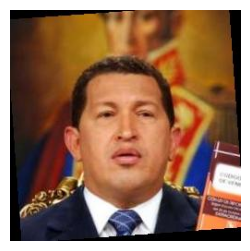

In [32]:
# plot picture
img = cv2.imread(EXAMPLE_PIC,  cv2.IMREAD_COLOR)
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
plt.figure(figsize=(3,3))
plt.grid(False)
plt.axis('off')
plt.imshow(img)

# Extreme Angles

#### Changing angle, size and position

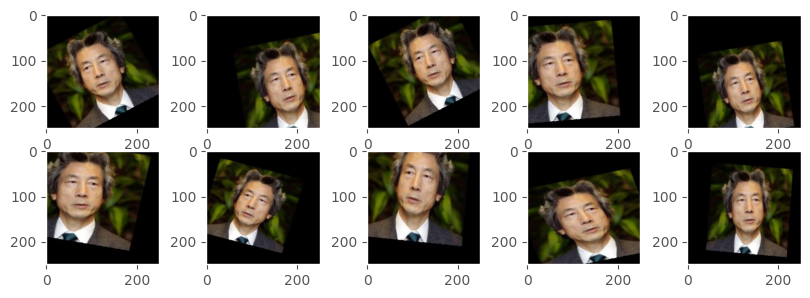

In [28]:
# Generate image generator for data augmentation
datagen =  ImageDataGenerator(
  #preprocessing_function=preprocess_input,
  rotation_range=30,
  width_shift_range=0.2,
  height_shift_range=0.2,
  shear_range=0.2,
  zoom_range=0.2,
  horizontal_flip=True
)

# load one image and reshape
img = load_img(EXAMPLE_PIC)
x = img_to_array(img)/255.
x = x.reshape((1,) + x.shape)

# plot 10 augmented images of the loaded iamge
plt.figure(figsize=(10,5))

i = 0
for batch in datagen.flow(x, batch_size=1):
    plt.subplot(3, 5, i+1)
    plt.grid(False)
    plt.imshow(batch[0]) # Access the first image in the batch

    if i == 9:
        break
    i += 1


plt.show()


In [29]:
face_detect = cv2.CascadeClassifier(cv2.data.haarcascades + "haarcascade_frontalface_default.xml")

def detect_face(img):
    face_img = img.copy()
    face_rects = face_detect.detectMultiScale(face_img)
    for (x,y,w,h) in face_rects:
        cv2.rectangle(face_img, (x,y), (x+w,y+h), (255,0,255), 2)

    return face_img


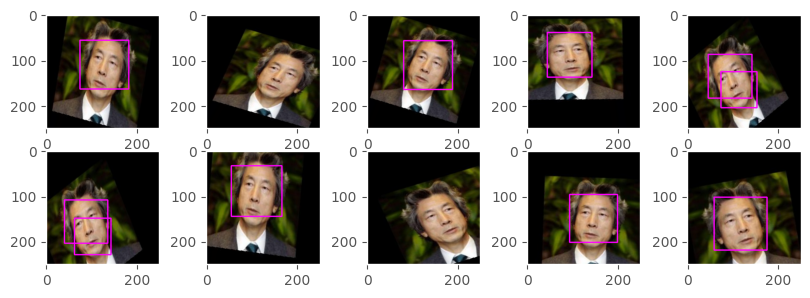

In [30]:
def detect_face(img):
    face_img = img.copy()
    # Convert the image to 8-bit unsigned integer format if it's not already
    face_img = (face_img * 255).astype('uint8')  # Assuming img is in the range [0, 1]
    face_rects = face_detect.detectMultiScale(face_img, scaleFactor=1.1)  # Adjust scaleFactor if needed
    for (x,y,w,h) in face_rects:
        cv2.rectangle(face_img, (x,y), (x+w,y+h), (255,0,255), 2)
    return face_img

# Generate image generator for data augmentation
datagen =  ImageDataGenerator(
  #preprocessing_function=preprocess_input,
  rotation_range=30,
  width_shift_range=0.2,
  height_shift_range=0.2,
  shear_range=0.2,
  zoom_range=0.2,
  horizontal_flip=True
)

# load one image and reshape
img = load_img(EXAMPLE_PIC)
x = img_to_array(img)/255.
x = x.reshape((1,) + x.shape)

# plot 10 augmented images of the loaded iamge
plt.figure(figsize=(10,5))

i = 0
for batch in datagen.flow(x, batch_size=1):
    plt.subplot(3, 5, i+1)
    plt.grid(False)
    plt.imshow(detect_face(batch[0]))

    if i == 9:
        break
    i += 1

plt.show()

In [39]:
face_detect = cv2.CascadeClassifier(cv2.data.haarcascades + "haarcascade_frontalface_default.xml")

def detect_face(img):
    face_img = img.copy()
    face_rects = face_detect.detectMultiScale(face_img)
    for (x,y,w,h) in face_rects:
        cv2.rectangle(face_img, (x,y), (x+w,y+h), (255,0,255), 2)

    return face_img

# Lighting

#### Dramatic filters/lighting changes

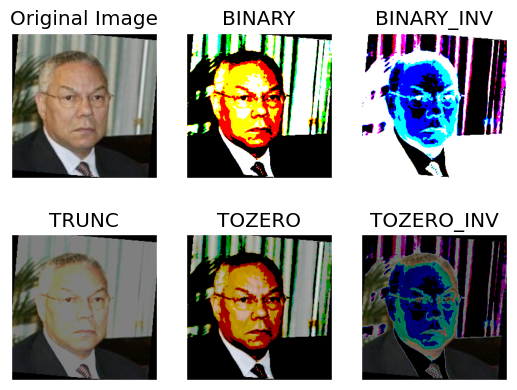

In [20]:
img = cv2.imread(EXAMPLE_PIC,  cv2.IMREAD_COLOR)
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
ret, thresh1 = cv2.threshold(img, 127, 255, cv2.THRESH_BINARY)
ret, thresh2 = cv2.threshold(img, 127, 255, cv2.THRESH_BINARY_INV)
ret, thresh3 = cv2.threshold(img, 127, 255, cv2.THRESH_TRUNC)
ret, thresh4 = cv2.threshold(img, 127, 255, cv2.THRESH_TOZERO)
ret, thresh5 = cv2.threshold(img, 127, 255, cv2.THRESH_TOZERO_INV)

titles = ['Original Image','BINARY','BINARY_INV','TRUNC','TOZERO','TOZERO_INV']
images = [img, thresh1, thresh2, thresh3, thresh4, thresh5]

for i in range(6):
    plt.subplot(2,3,i+1),plt.imshow(images[i],'gray')
    plt.title(titles[i])
    plt.xticks([]),plt.yticks([])
plt.show()

#### Detecting the face with dramatic filters/lighting

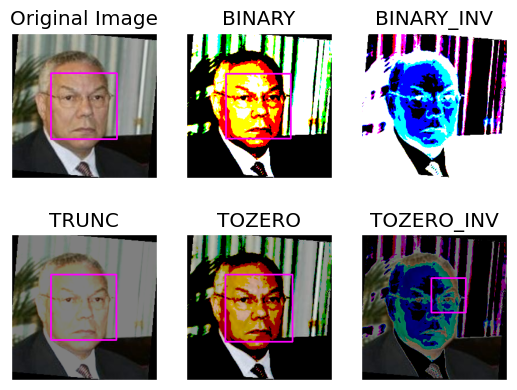

In [21]:
for i in range(6):
    plt.subplot(2,3,i+1),plt.imshow(detect_face(images[i]))
    plt.title(titles[i])
    plt.xticks([]),plt.yticks([])
plt.show()

#### Realistic Lighting (Blurry photo)

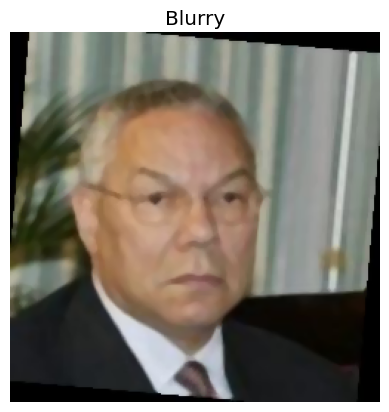

In [18]:
median = cv2.medianBlur(img, 5)
plt.grid(False)
plt.title('Blurry')
plt.axis('off')
plt.imshow(median)

#### Detecting a the blurred face

Text(0.5, 1.0, 'Blurry')

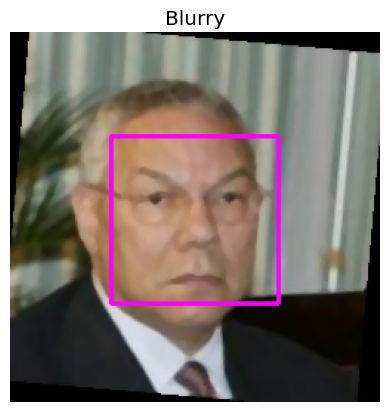

In [19]:
plt.imshow(detect_face(median))
plt.grid(False)
plt.axis('off')
plt.title('Blurry')

#### Low Lighting

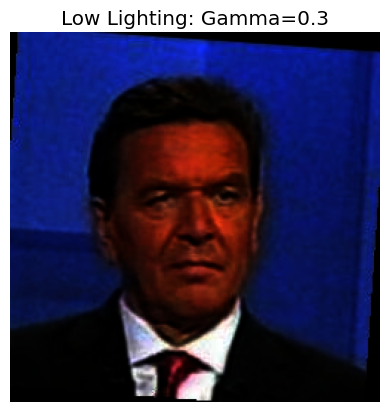

In [6]:
from __future__ import print_function
import numpy as np
import argparse
import cv2

img = cv2.imread(EXAMPLE_PIC,  cv2.IMREAD_COLOR)
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

def adjust_gamma(image, gamma=1.0):
	# build a lookup table mapping the pixel values [0, 255] to
	# their adjusted gamma values
	invGamma = 1.0 / gamma
	table = np.array([((i / 255.0) ** invGamma) * 255
		for i in np.arange(0, 256)]).astype("uint8")
	# apply gamma correction using the lookup table
	return cv2.LUT(image, table)

#when gamma is anything lower than or equal to 0.2 (dark) or anything higher than or equal to 36 (bright), it cant detect a face
img = adjust_gamma(img, gamma=0.3)
plt.grid(False)
plt.title('Low Lighting: Gamma=0.3')
plt.axis('off')
plt.imshow(img)

Text(0.5, 1.0, 'Low Lighting: Gamma=0.3')

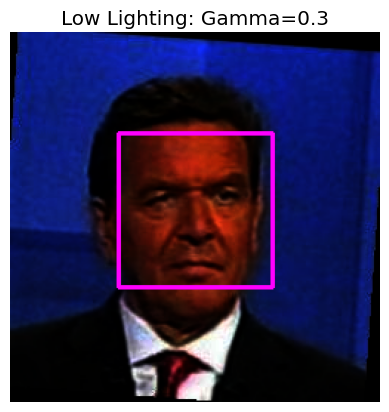

In [9]:
plt.imshow(detect_face(img))
plt.grid(False)
plt.axis('off')
plt.title('Low Lighting: Gamma=0.3')

# Occlusion


### Adding sunglass, a hat and a face mask to the images

In [13]:
sun = '/content/gdrive/My Drive/Masters/sunglasses.png'
hat =  '/content/gdrive/My Drive/Masters/hat.png'
mask = '/content/gdrive/My Drive/Masters/mask.png'

In [35]:
pic2 = cv2.imread(sun)
pic2 = cv2.cvtColor(pic2, cv2.COLOR_BGR2RGB)
pic3 = cv2.imread(hat)
pic3 = cv2.cvtColor(pic3, cv2.COLOR_BGR2RGB)
pic4 = cv2.imread(mask)
pic4 = cv2.cvtColor(pic4, cv2.COLOR_BGR2RGB)

Text(0.5, 1.0, 'Sunglasses')

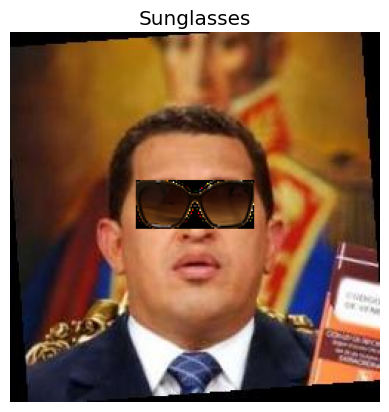

In [40]:
pic1 = cv2.imread(EXAMPLE_PIC)
pic1 = cv2.cvtColor(pic1, cv2.COLOR_BGR2RGB)
bigimg = pic1
smallimg = pic2

x_offset=85
y_offset=100

bigimg[y_offset:y_offset+smallimg.shape[0], x_offset:x_offset+smallimg.shape[1]] = smallimg
plt.imshow(bigimg)
plt.grid(False)
plt.axis('off')
plt.title('Sunglasses')


Text(0.5, 1.0, 'Sunglasses')

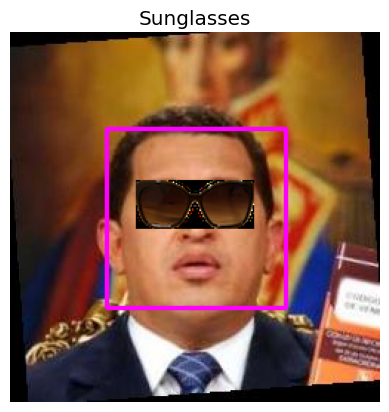

In [41]:
plt.imshow(detect_face(bigimg))
plt.grid(False)
plt.axis('off')
plt.title('Sunglasses')

Text(0.5, 1.0, 'Hat')

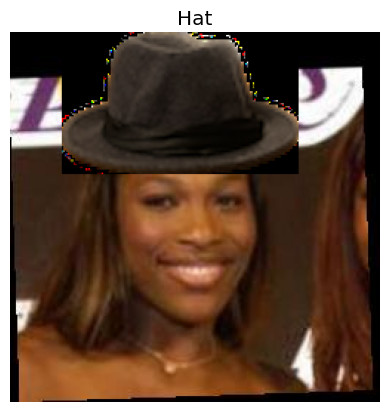

In [20]:
pic1 = cv2.imread(EXAMPLE_PIC)
pic1 = cv2.cvtColor(pic1, cv2.COLOR_BGR2RGB)
bigimg = pic1
smallimg = pic3

x_offset=35
y_offset=0

bigimg[y_offset:y_offset+smallimg.shape[0], x_offset:x_offset+smallimg.shape[1]] = smallimg
plt.imshow(bigimg)
plt.grid(False)
plt.axis('off')
plt.title('Hat')

Text(0.5, 1.0, 'Hat')

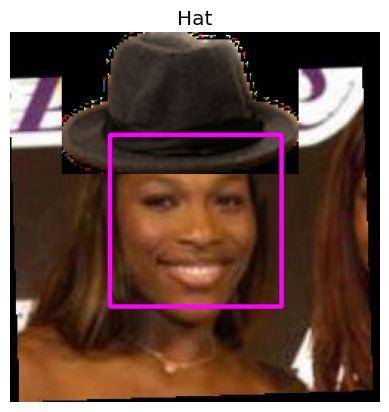

In [21]:
plt.imshow(detect_face(bigimg))
plt.grid(False)
plt.axis('off')
plt.title('Hat')

Text(0.5, 1.0, 'Mask')

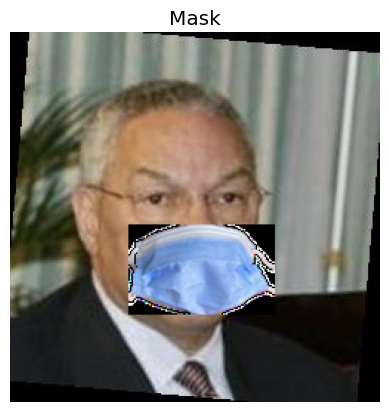

In [16]:
pic1 = cv2.imread(EXAMPLE_PIC)
pic1 = cv2.cvtColor(pic1, cv2.COLOR_BGR2RGB)
bigimg = pic1
smallimg = pic4

x_offset=80
y_offset=130

bigimg[y_offset:y_offset+smallimg.shape[0], x_offset:x_offset+smallimg.shape[1]] = smallimg
plt.imshow(bigimg)
plt.grid(False)
plt.axis('off')
plt.title('Mask')

Text(0.5, 1.0, 'Mask')

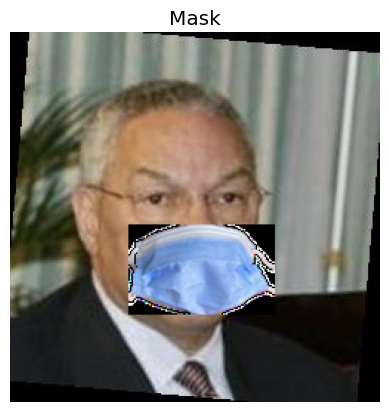

In [17]:
plt.imshow(detect_face(bigimg))
plt.grid(False)
plt.axis('off')
plt.title('Mask')